In [5]:
import os
import csv
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import plot_utils as pu
from scipy.stats import pearsonr, spearmanr
from matplotlib.lines import Line2D

''' READ BETWEENNESS FILES FROM DIFFERENT GRAPHS AND THE NODE POSITIONS TO PLOT HEXBIN '''

# lattice graphs vx2
# direct_bwss = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/ksp_python/other_path_sampling_methods/penalized_bwss/lattice/vx2/02_tol/k50/p005/'
# pos_dir = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/lattice_roads/vx2/node_pos/'
# graph_dir = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/lattice_roads/vx2/graph_variations/'

# ring graphs vx1
direct_bwss = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/KSP_python/other_path_sampling_methods/penalized_bwss/ring/vx2/03_tol/k50/p01/'
pos_dir = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/ring_roads/vx2/node_pos/'
graph_dir = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/ring_roads/vx2/graph_variations/'
direct_rsp = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/ring_roads/vx2/'

nnodes = 58

max value: 0.20221611577523776 at position: [-0.50000562 -0.47824866]


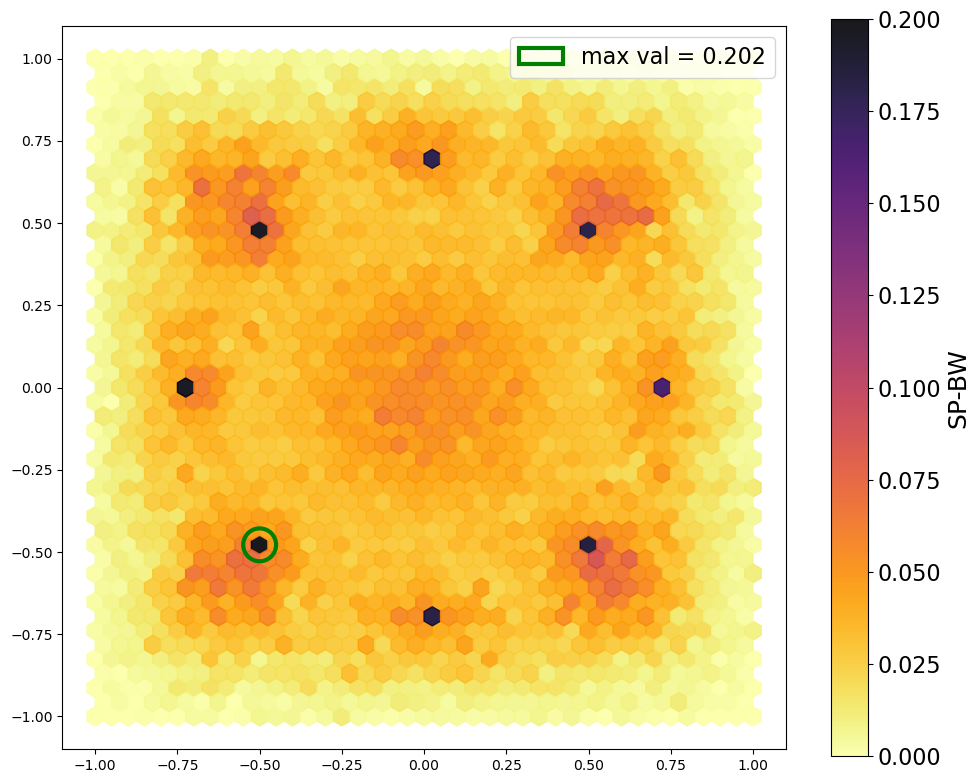

max value: 0.1603239664992124 at position: [0.49996099 0.47823409]


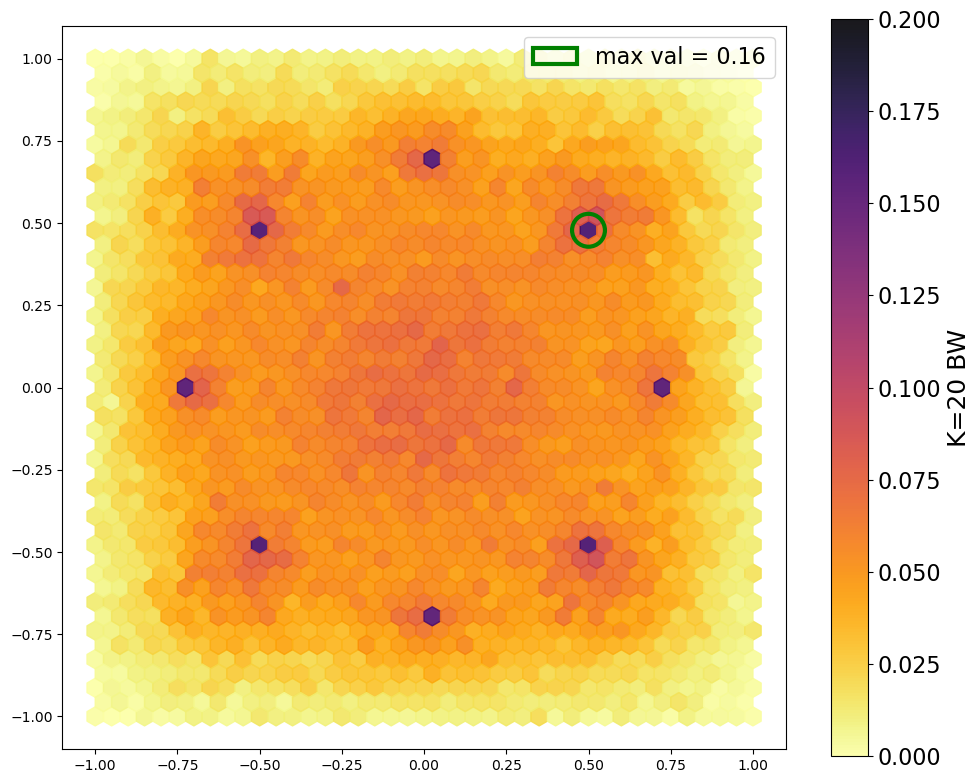

max value: 0.032027531879443405 at position: [-0.25001397  0.30432813]


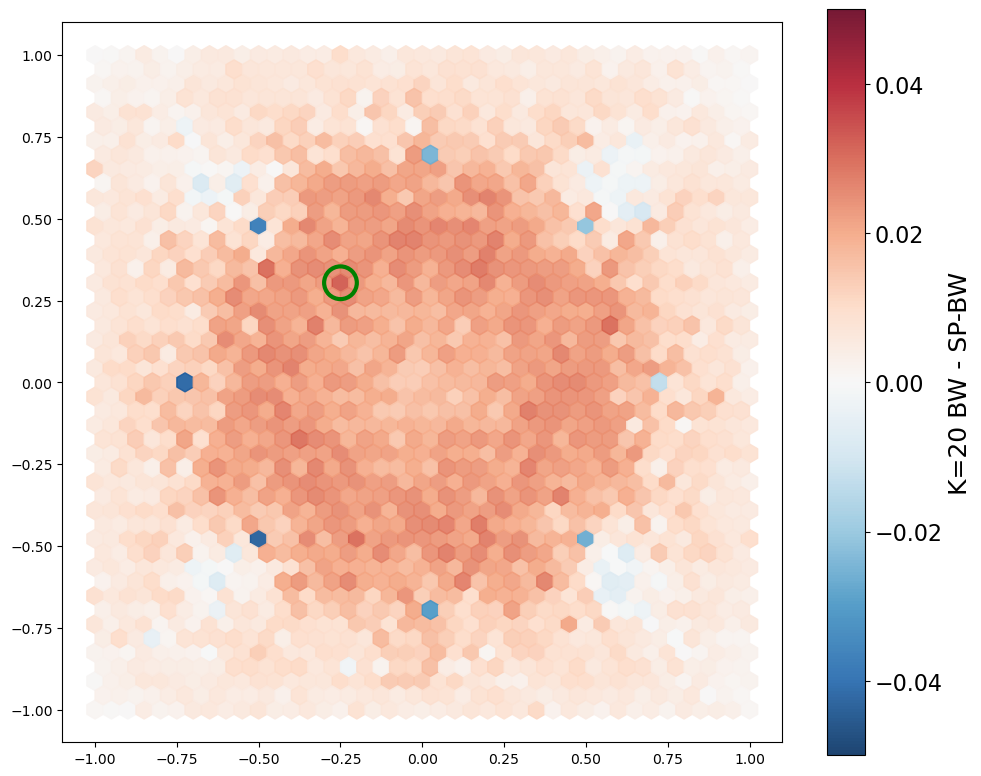

max value: 0.20027147064379974 at position: [0.49996099 0.47823409]


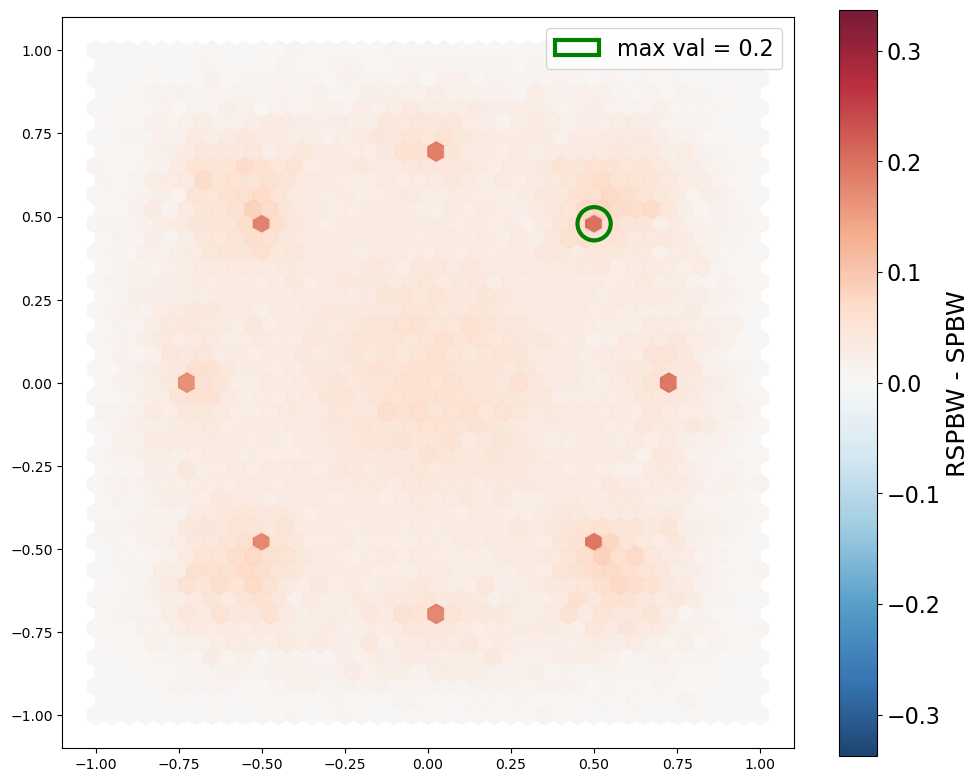

In [ ]:
x_pos_tot = []
y_pos_tot = []
count = 0
pen_bwss_ls = []
rsp_bwss_ls = []
sp_bwss_ls = []
for bw_file in os.listdir(direct_bwss):
    if bw_file.endswith('.csv'):
        x_pos = list(np.zeros(nnodes))
        y_pos = list(np.zeros(nnodes))
        ind = ''
        for char in bw_file:
            if char.isdigit():
                ind += char
            elif char == '_':
                break
        pos_i_dir = pos_dir + 'pos_ring' + ind + '.csv'
        graph_i_dir = graph_dir + 'ring' + ind + '.csv'
        direct_rsp_i = direct_rsp + 'bwss_' + ind + '/rsp_bw_2.csv'
        count += 1
        # read the node positions
        with open(pos_i_dir, 'r') as csvfile:
            csvreader = csv.reader(csvfile, delimiter=',')
            csvreader.__next__()  # Skip header row
            for row in csvreader:
                if row[0].isdigit(): 
                    x_pos[int(row[0])] = float(row[1])
                    y_pos[int(row[0])] = float(row[2])
        x_pos_tot += x_pos
        y_pos_tot += y_pos
        
        # read the graph
        df = pd.read_csv(graph_i_dir)  # header handled automatically
        G = nx.from_pandas_edgelist(
            df, source="vertex1", target="vertex2",
            edge_attr="edge_weight", create_using=nx.Graph())

        # compute SP betweenness
        bwss_sp = nx.betweenness_centrality(G, normalized=True, weight='edge_weight')
        # store in list
        sp_bwss = []
        for node in range(len(G.nodes)):
            sp_bwss.append(bwss_sp[node])
        sp_bwss_ls += sp_bwss
        pen_bwss_ls_file = list(np.zeros(nnodes))
        with open(direct_bwss+bw_file, 'r') as csvfile:
            csvreader = csv.reader(csvfile, delimiter=',')
            for i, row in enumerate(csvreader):

                pen_bwss_ls_file[i] = float(row[0])  
            
        pen_bwss_ls += pen_bwss_ls_file

        rsp_bwss_ls_file = list(np.zeros(nnodes))
        with open(direct_rsp_i, 'r') as csvfile:
            csvreader = csv.reader(csvfile, delimiter=',')
            for i, row in enumerate(csvreader):

                rsp_bwss_ls_file[i] = float(row[0])  

        rsp_bwss_ls += rsp_bwss_ls_file        

pu.plot_hexbin_with_max(
    x_pos_tot, y_pos_tot, np.array(sp_bwss_ls),
    gridsize=40, mincnt=1,
    vmin=0.0, vmax=0.2,
    cmap_name='inferno_r',
    max_marker_radius=0.05,
    axis_off=False,
    annotate_max=True,
    cbar_label=r'SP-BW',
);
plt.show()

pu.plot_hexbin_with_max(
    x_pos_tot, y_pos_tot, np.array(pen_bwss_ls),
    gridsize=40, mincnt=1,
    vmin=0.0, vmax=0.2,
    cmap_name='inferno_r',
    max_marker_radius=0.05,
    axis_off=False,
    annotate_max=True,
    cbar_label=r'K=20 BW',
);
plt.show()

pu.plot_hexbin_with_max(
    x_pos_tot, y_pos_tot, np.array(pen_bwss_ls)-np.array(sp_bwss_ls),
    gridsize=40, mincnt=1,
    vmin=-0.05, vmax=0.05,
    cmap_name='RdBu_r',
    max_marker_radius=0.05,
    axis_off=False,
    annotate_max=False,
    cbar_label=r'K=20 BW - SP-BW',
);
plt.show()
diff = np.array(rsp_bwss_ls)-np.array(sp_bwss_ls)
pu.plot_hexbin_with_max(
    x_pos_tot, y_pos_tot, diff,
    gridsize=40, mincnt=1,
    vmin=-max(diff), vmax=max(diff),
    cmap_name='RdBu_r',
    max_marker_radius=0.05,
    axis_off=False,
    annotate_max=True,
    cbar_label=r'RSPBW - SPBW',
);
plt.show()

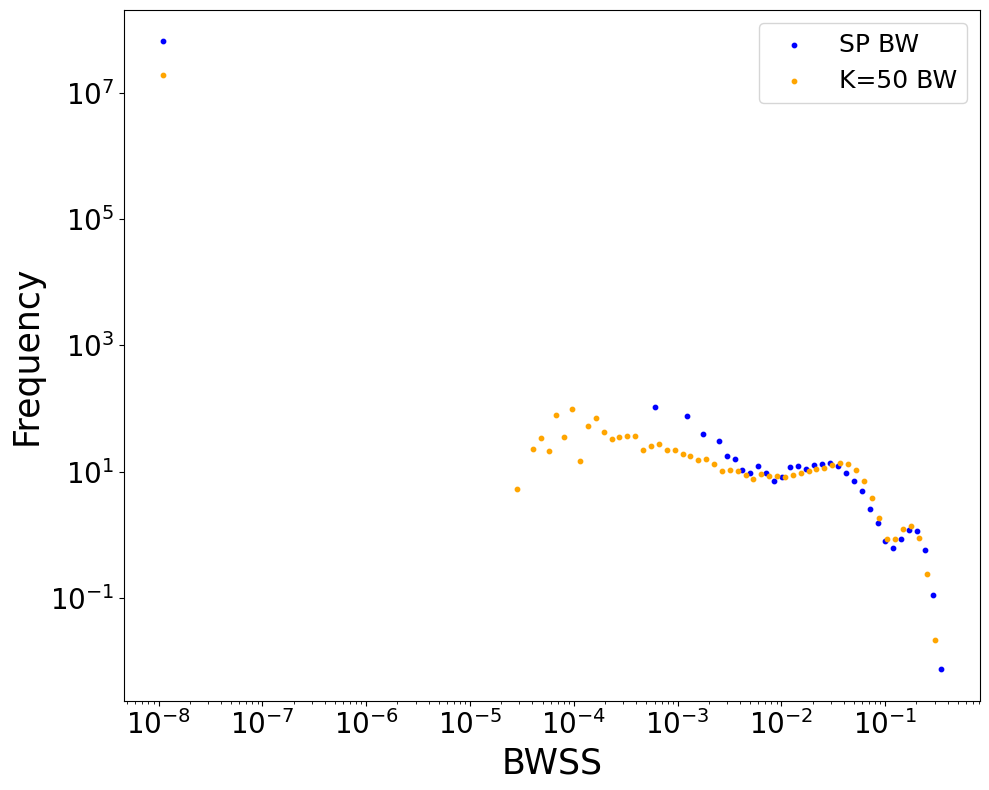

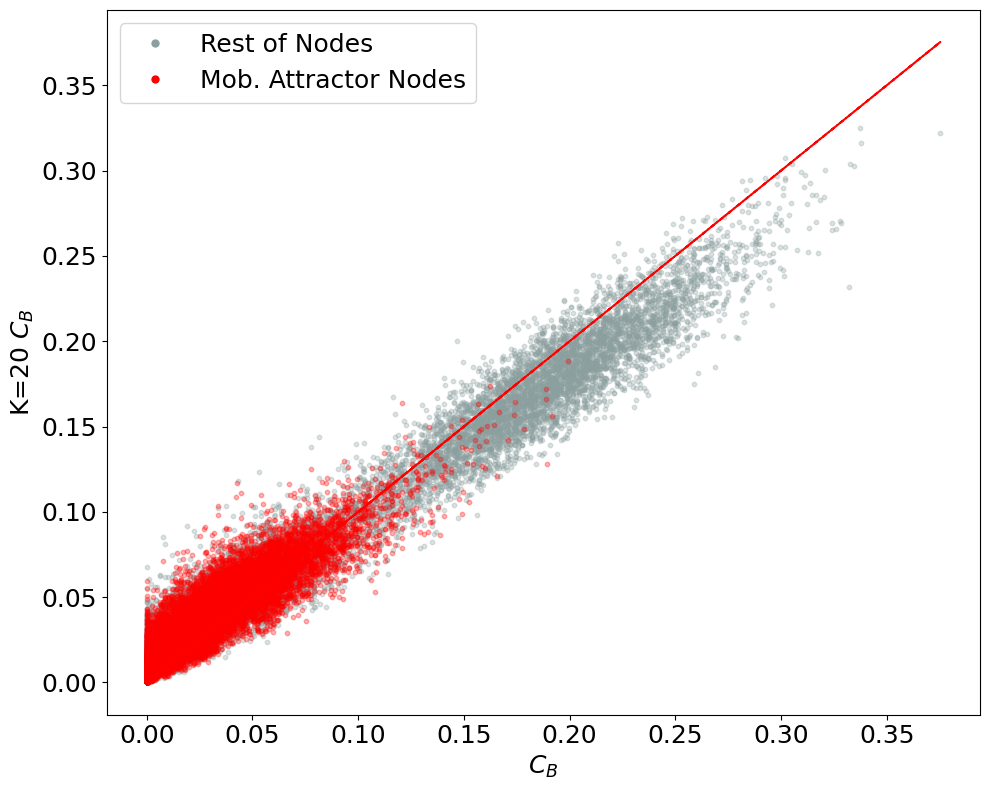

In [293]:
# plot histogram of betweenness values

plt.figure(figsize=(10, 8))
cols = ['blue', 'orange', 'green', 'red']
# cmap1 = plt.colormaps['Blues']
# cmap2 = plt.colormaps['Oranges']
# cmap3 = plt.colormaps['Greens']
# cmap4 = plt.colormaps['Reds']
# cmap_ls = [cmap1, cmap2, cmap3, cmap4]
# r_pos_hb = np.array([np.linalg.norm(np.array([x, y])) for x, y in hb.get_offsets()])

bwss_list = [sp_bwss_ls, pen_bwss_ls]
str_ls = ['SP', 'K=50']
for i in range(len(bwss_list)):

    # data, bins = np.histogram(tot_tol_bw[i], bins=100)
    tol_i = np.array(bwss_list[i])
    tol_i[tol_i == 0] = 10e-9 # Replace zeros with a small value to avoid log(0)
    # Step 1: Define log-spaced bins
    bins = np.logspace(np.log10(min(tol_i[tol_i>0])), max(np.log10(tol_i)), num=100)
    # Step 2: Compute histogram
    counts, edges = np.histogram(tol_i, bins=bins, density=True)

    # Step 3: Get bin centers
    centers = (edges[:-1] + edges[1:]) / 2
    # plot of distribution in loglog

    # bins_new = bins[:-1] + (bins[1]-bins[0])/2  # Adjust bins to center the ticks
    plt.scatter(centers, counts, s=10, alpha=1, color = cols[i], label=f'{str_ls[i]} BW')
plt.semilogx()
plt.semilogy()
plt.ylabel('Frequency', fontsize = 25)
plt.xlabel(r'BWSS', fontsize = 25)
plt.legend(fontsize = 18)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.tight_layout()
plt.show()


#% plot correlation
plt.figure(figsize=(10, 8))
plt.xlabel(r'$C_B$', fontsize = 18)
plt.ylabel(r'K=20 $C_B$', fontsize = 18)

bw_0 = []
bw_tol = []
mob_attractor_bw_0 = []
mob_attractor_bw_tol = []

plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
tol_y = pen_bwss_ls
for i in range(count):
    start = nnodes*i
    mob_attractor_bw_0 += sp_bwss_ls[start+nnodes-28:start+nnodes]
    mob_attractor_bw_tol += tol_y[start+nnodes-28:start+nnodes]
    bw_0 += sp_bwss_ls[start:start+nnodes-28]
    bw_tol += tol_y[start:start+nnodes-28]
    

pear_rest = pearsonr(bw_0, bw_tol)
# pear_tot = pearsonr(ring_bw_0+rest_0, ring_bw_tol+rest_tol)



plt.scatter(bw_0, bw_tol, s = 10, alpha = 0.3, c = '#8C9F9F', 
            label = 'non attractor nodes')
plt.scatter(mob_attractor_bw_0, mob_attractor_bw_tol, s = 10, alpha = 0.3, c = 'red', 
            label = 'attractor nodes')

    
plt.plot(bw_0, bw_0, c = 'r', linestyle = '--', label = 'y = x')

# Custom legend handles
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Rest of Nodes',
           markerfacecolor='#8C9F9F', markersize=7),
    Line2D([0], [0], marker='o', color='w', label='Mob. Attractor Nodes',
           markerfacecolor='red', markersize=7)
]

# Add legend to the plot
plt.legend(handles=legend_elements, loc='upper left', fontsize = 18)
plt.tight_layout()
plt.show()

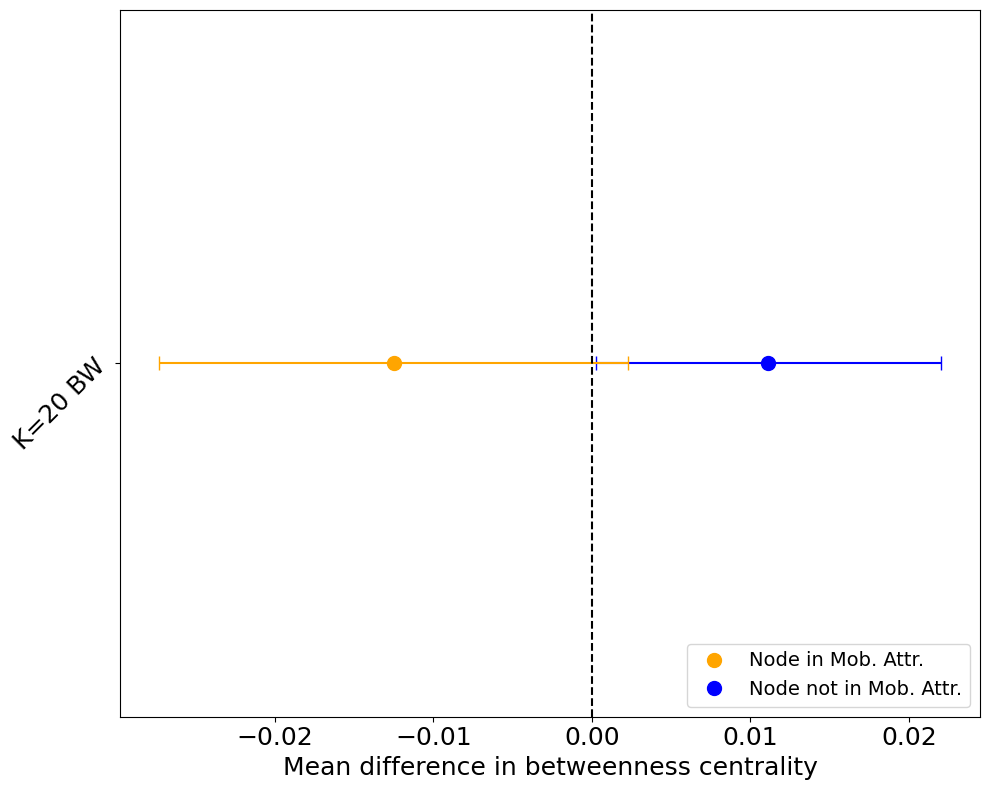

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

diff_1 = np.array(bw_tol) - np.array(bw_0)
diff_2 = np.array(mob_attractor_bw_tol) - np.array(mob_attractor_bw_0)

ax.scatter(np.mean(diff_1), 1, c='blue', marker = 'o', s=100)
ax.scatter(np.mean(diff_2), 1, c='orange', marker = 'o', s=100)

ax.errorbar(np.mean(diff_1), 1, xerr = np.std(diff_1), c='blue', capsize= 5)
ax.errorbar(np.mean(diff_2), 1, xerr = np.std(diff_2), c='orange', capsize= 5)

ax.tick_params(labelsize=18)
ax.set_xlabel('Mean difference in betweenness centrality', fontsize=18)

r_p = Line2D([0], [0], label='Node in Mob. Attr.', marker='o', markersize=10, 
         markeredgecolor='orange', markerfacecolor='orange', linestyle='')
g_p = Line2D([0], [0], label='Node not in Mob. Attr.', marker='o', markersize=10, 
         markeredgecolor='blue', markerfacecolor='blue', linestyle='')


ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
# Add the legend
plt.legend([r_p, g_p],
    ["Node in Mob. Attr.",
     "Node not in Mob. Attr."],
    fontsize=14,
    loc='lower right',
    frameon=True
)
ax.set_yticks([1])
ax.set_yticklabels(["K=20 BW"], rotation = 45, fontsize=18)
plt.tight_layout()
plt.show()

## COMPARING PENALIZED BWSS VS QSP-BWSS

In [6]:
import numpy as np
from scipy.io import loadmat

def _load_cell_matrix(mat_path):
    """
    Load the first MATLAB variable from a .mat file and validate it is a
    MATLAB cell array (object-typed NumPy ndarray).

    Parameters
    ----------
    mat_path : str or path-like
        Path to the .mat file.

    Returns
    -------
    numpy.ndarray
        Object-typed ndarray representing the MATLAB cell array.

    Raises
    ------
    ValueError
        If the .mat file contains no user variables.
    TypeError
        If the first variable is not an object-typed ndarray (cell array).
    """
    mat = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    keys = [k for k in mat if not k.startswith('__')]
    if not keys:
        raise ValueError("no variables in MAT")
    arr = mat[keys[0]]
    if not (isinstance(arr, np.ndarray) and arr.dtype == object):
        raise TypeError("expected a MATLAB cell array (object ndarray)")
    return arr

def compute_qsp_bw_from_file(bw_fname, tol, nnodes, normalized=True, directed=False):
    """
    Compute QSP-based node betweenness from a MATLAB cell array on disk.

    Each cell (s, t) holds an array of candidate paths from s to t, with shape
    M x (nnodes+1): the first nnodes columns list node IDs (0-padded), and the
    last column stores the path length. Paths within a (1+tol) factor of the
    shortest candidate length are retained (using the first row as baseline).
    Endpoints (s, t) are excluded from counts.

    Parameters
    ----------
    bw_fname : str or path-like
        Path to the .mat file containing the path list cell array.
    tol : float
        Length tolerance. If > 1 it is interpreted as a percentage (e.g., 20
        means 20%); otherwise as a fraction (e.g., 0.2).
    nnodes : int
        Number of nodes (ignored and overwritten by cell array shape).
    normalized : bool, optional
        If True, apply betweenness normalization by (nnodes-1)(nnodes-2)
        (and a factor 2 for undirected), by default True.
    directed : bool, optional
        Whether the graph is directed, by default False.

    Returns
    -------
    numpy.ndarray
        Array of shape (nnodes,) with QSP-based betweenness scores.

    Raises
    ------
    ValueError
        If any (s, t) cell has an unexpected number of columns.
    """
    if tol > 1:
        tol = tol / 100.0

    PathLisArr = _load_cell_matrix(bw_fname)
    nnodes = PathLisArr.shape[0]
    qsp_bw = np.zeros(nnodes, dtype=np.float64)

    col_idx = np.arange(1, nnodes + 1, dtype=np.int32)  # 1..nnodes

    for s in range(nnodes):
        for t in range(s + 1, nnodes):
            path_ls = PathLisArr[s, t]
            if path_ls is None or (isinstance(path_ls, float) and np.isnan(path_ls)):
                continue
            A = np.asarray(path_ls)
            if A.size == 0:
                continue
            if A.ndim == 1:
                A = A.reshape(1, -1)

            # Expect M x (nnodes+1)
            if A.shape[1] != nnodes + 1:
                raise ValueError(f"cell({s},{t}) has {A.shape[1]} cols, expected {nnodes+1}")

            # length tolerance: assumes first row’s length is the baseline (as in MATLAB code)
            max_len = A[0, nnodes] * (1.0 + tol)

            # --- fix trailing filler zeros to -1 in node columns (vectorized)
            nodes = A[:, :nnodes]
            # Work in int32 for fast bincount (cast once)
            # NOTE: nodes can be float from MATLAB; -1 must remain -1 after cast
            nodes_i = nodes.astype(np.int32, copy=False)

            nz = (nodes_i != 0)
            lastNZ = (nz * col_idx).max(axis=1)  # per-row last nonzero col index, 0 if none
            mask_tail = col_idx > lastNZ[:, None]
            # set zeros strictly after lastNZ to -1
            tail_zeros = mask_tail & (nodes_i == 0)
            if tail_zeros.any():
                nodes_i[tail_zeros] = -1

            # keep paths within tolerance
            keep = A[:, nnodes] <= max_len
            if not np.any(keep):
                continue
            node_block = nodes_i[keep, :]

            # --- vectorized counting: histogram of all node IDs in kept paths
            # flatten and drop negatives (-1) and endpoints s,t
            flat = node_block.ravel()
            valid = flat >= 0
            if not np.any(valid):
                continue

            flat = flat[valid]
            # zero out counts for s and t after bincount
            counts = np.bincount(flat, minlength=nnodes).astype(np.float64)
            counts[s] = 0.0
            counts[t] = 0.0

            n_p_in_tol = int(keep.sum())
            if n_p_in_tol > 0:
                qsp_bw += counts / n_p_in_tol

    # normalization
    if normalized:
        denom = (nnodes - 1) * (nnodes - 2)
        if denom > 0:
            qsp_bw = (qsp_bw / denom) if directed else (2.0 *qsp_bw / denom)

    return qsp_bw

from typing import Sequence, Hashable, Tuple, Set

Node = Hashable
Edge = Tuple[Node, Node]

def edge_set(path: Sequence[Node], directed: bool=False) -> Set[Edge]:
    """
    Convert a path (sequence of nodes) into a set of edges.

    Parameters
    ----------
    path : Sequence[Hashable]
        Node sequence defining the path.
    directed : bool, optional
        If True, keep edges ordered (u, v). If False, canonicalize undirected
        edges so (u, v) == (v, u), by default False.

    Returns
    -------
    set[tuple]
        Set of edges along the path, respecting the directedness.
    """
    pairs = list(zip(path, path[1:]))          # consecutive edges
    if directed:
        return set(pairs)
    # undirected: canonicalize so (u,v)==(v,u)
    return { (u,v) if u <= v else (v,u) for u,v in pairs }

def compute_overlap_qsp_bw_from_file(bw_fname, tol, overlap, nnodes, normalized=True, directed=False):
    """
    Compute QSP-based node betweenness with an overlap constraint among kept
    paths, from a MATLAB cell array on disk.

    For each (s, t), candidate paths within a (1+tol) length factor are first
    selected. Among those, paths are greedily filtered so that the overlap
    ratio (|E(cand) ∩ E(ref)| / |E(ref)|) does not exceed `overlap` against
    already kept references (first kept path is the first candidate). Endpoints
    (s, t) are excluded from counts.

    Parameters
    ----------
    bw_fname : str or path-like
        Path to the .mat file containing the path list cell array.
    tol : float
        Length tolerance. If > 1 it is interpreted as a percentage; otherwise
        as a fraction.
    overlap : float
        Maximum allowed overlap ratio against each kept reference path.
    nnodes : int
        Number of nodes (ignored and overwritten by cell array shape).
    normalized : bool, optional
        If True, apply standard betweenness normalization, by default True.
    directed : bool, optional
        Whether the graph is directed, by default False.

    Returns
    -------
    numpy.ndarray
        Array of shape (nnodes,) with overlap-constrained QSP betweenness.

    Raises
    ------
    ValueError
        If any (s, t) cell has an unexpected number of columns.
    """
    if tol > 1:
        tol = tol / 100.0

    PathLisArr = _load_cell_matrix(bw_fname)
    nnodes = PathLisArr.shape[0]
    qsp_bw = np.zeros(nnodes, dtype=np.float64)

    col_idx = np.arange(1, nnodes + 1, dtype=np.int32)  # 1..nnodes

    for s in range(nnodes):
        for t in range(s + 1, nnodes):
            path_ls = PathLisArr[s, t]
            if path_ls is None or (isinstance(path_ls, float) and np.isnan(path_ls)):
                continue
            A = np.asarray(path_ls)
            if A.size == 0:
                continue
            if A.ndim == 1:
                A = A.reshape(1, -1)

            if A.shape[1] != nnodes + 1:
                raise ValueError(f"cell({s},{t}) has {A.shape[1]} cols, expected {nnodes+1}")

            max_len = A[0, nnodes] * (1.0 + tol)

            nodes = A[:, :nnodes]
            nodes_i = nodes.astype(np.int32, copy=False)

            nz = (nodes_i != 0)
            lastNZ = (nz * col_idx).max(axis=1)
            mask_tail = col_idx > lastNZ[:, None]
            tail_zeros = mask_tail & (nodes_i == 0)
            if tail_zeros.any():
                nodes_i[tail_zeros] = -1

            keep = A[:, nnodes] <= max_len
            keep_idx = np.flatnonzero(keep)
            if keep_idx.size == 0:
                continue

            sub_block = nodes_i[keep_idx, :]

            if keep_idx.size > 1 and overlap > 0:
                edge_sets = []
                for row in sub_block:
                    path_nodes = row[row >= 0]
                    if path_nodes.size < 2:
                        edge_sets.append(frozenset())
                        continue
                    if directed:
                        edges = frozenset(zip(path_nodes[:-1], path_nodes[1:]))
                    else:
                        edges = frozenset((min(u, v), max(u, v)) for u, v in zip(path_nodes[:-1], path_nodes[1:]))
                    edge_sets.append(edges)

                sub_keep = np.ones(sub_block.shape[0], dtype=bool)
                kept_refs = [0]
                for sub_idx in range(1, sub_block.shape[0]):
                    if not sub_keep[sub_idx]:
                        continue
                    cand_edges = edge_sets[sub_idx]
                    reject = False
                    for ref_idx in kept_refs:
                        ref_edges = edge_sets[ref_idx]
                        # union_size = len(cand_edges | ref_edges)

                        overlap_ratio = (len(cand_edges & ref_edges) / len(ref_edges))
                        if overlap_ratio > overlap:
                            sub_keep[sub_idx] = False
                            reject = True
                            break
                    if not reject:
                        kept_refs.append(sub_idx)

                sub_block = sub_block[sub_keep, :]
                if sub_block.shape[0] == 0:
                    continue

            flat = sub_block.ravel()
            valid = flat >= 0
            if not np.any(valid):
                continue

            flat = flat[valid]
            counts = np.bincount(flat, minlength=nnodes).astype(np.float64)
            counts[s] = 0.0
            counts[t] = 0.0

            n_p_in_tol = sub_block.shape[0]
            if n_p_in_tol > 0:
                qsp_bw += counts / n_p_in_tol

    if normalized:
        denom = (nnodes - 1) * (nnodes - 2)
        if denom > 0:
            qsp_bw = (qsp_bw / denom) if directed else (2.0 * qsp_bw / denom)

    return qsp_bw



In [7]:
# qsp_dir = '../../../MCM/mcm/lattice_road_p_structure_vx2/'
# direct_bwss = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/ksp_python/other_path_sampling_methods/penalized_bwss/lattice/vx2/02_tol/k50/p005/'
# pos_dir = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/lattice_roads/vx2/node_pos/'
# graph_dir = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/lattice_roads/vx2/graph_variations/'

qsp_dir = '../../../MCM/mcm/ring_road_p_structure_vx1/'
direct_bwss = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/KSP_python/other_path_sampling_methods/penalized_bwss/ring/vx1/02_tol/k50/p005/'
pos_dir = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/ring_roads/vx1/node_pos/'
graph_dir = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/ring_roads/vx1/graph_variations/'


nnodes = 58
x_pos_tot = []
y_pos_tot = []
count = 0
pen_bwss_ls = []
sp_bwss_ls = []
qsp_bwss_ls = []
qsp_bwss_ov_ls = []
for bw_file in os.listdir(direct_bwss):
    if bw_file.endswith('.csv'):
        x_pos = list(np.zeros(nnodes))
        y_pos = list(np.zeros(nnodes))
        ind = ''
        for char in bw_file:
            if char.isdigit():
                ind += char
            elif char == '_':
                break
        pos_i_dir = pos_dir + 'pos_ring' + ind + '.csv'
        graph_i_dir = graph_dir + 'ring' + ind + '.csv'
        count += 1

        graph_p_dir = qsp_dir + "ring_road_"+ind + "/path_ls_mat_20.mat"
        try:
            # compute QSP betweenness
            bwss_qsp = compute_qsp_bw_from_file(graph_p_dir, tol=0.2, nnodes = nnodes, normalized=True, directed=False)
            bwss_qsp_ov = compute_overlap_qsp_bw_from_file(graph_p_dir, tol=0.2, overlap = 0.5, nnodes = nnodes, normalized=True, directed=False)
            # store in list
            qsp_bwss_ls += list(bwss_qsp)  
            qsp_bwss_ov_ls += list(bwss_qsp_ov)  

        except Exception as e:
            print(f"Error processing file {graph_p_dir}: {e}")
            continue

        # read the node positions
        with open(pos_i_dir, 'r') as csvfile:
            csvreader = csv.reader(csvfile, delimiter=',')
            csvreader.__next__()  # Skip header row
            for row in csvreader:
                if row[0].isdigit(): 
                    x_pos[int(row[0])] = float(row[1])
                    y_pos[int(row[0])] = float(row[2])
        x_pos_tot += x_pos
        y_pos_tot += y_pos
        
        # read the graph
        df = pd.read_csv(graph_i_dir)  # header handled automatically
        G = nx.from_pandas_edgelist(
            df, source="vertex1", target="vertex2",
            edge_attr="edge_weight", create_using=nx.Graph())
        # compute SP betweenness
        bwss_sp = nx.betweenness_centrality(G, normalized=True, weight='edge_weight', endpoints=False)
        # store in list
        sp_bwss = []
        for node in range(len(G.nodes)):
            sp_bwss.append(bwss_sp[node])
        sp_bwss_ls += sp_bwss
        pen_bwss_ls_file = []
        with open(direct_bwss+bw_file, 'r') as csvfile:
            csvreader = csv.reader(csvfile, delimiter=',')
            for i, row in enumerate(csvreader):

                pen_bwss_ls_file.append(float(row[0]))

        pen_bwss_ls += pen_bwss_ls_file  

          


Error processing file ../../../MCM/mcm/ring_road_p_structure_vx1/ring_road_31/path_ls_mat_20.mat: [Errno 2] No such file or directory: '../../../MCM/mcm/ring_road_p_structure_vx1/ring_road_31/path_ls_mat_20.mat'
Error processing file ../../../MCM/mcm/ring_road_p_structure_vx1/ring_road_515/path_ls_mat_20.mat: [Errno 2] No such file or directory: '../../../MCM/mcm/ring_road_p_structure_vx1/ring_road_515/path_ls_mat_20.mat'
Error processing file ../../../MCM/mcm/ring_road_p_structure_vx1/ring_road_850/path_ls_mat_20.mat: [Errno 2] No such file or directory: '../../../MCM/mcm/ring_road_p_structure_vx1/ring_road_850/path_ls_mat_20.mat'
Error processing file ../../../MCM/mcm/ring_road_p_structure_vx1/ring_road_288/path_ls_mat_20.mat: [Errno 2] No such file or directory: '../../../MCM/mcm/ring_road_p_structure_vx1/ring_road_288/path_ls_mat_20.mat'
Error processing file ../../../MCM/mcm/ring_road_p_structure_vx1/ring_road_677/path_ls_mat_20.mat: [Errno 2] No such file or directory: '../../../

603.0
[0.051995771381430446, 0.01626455675242313, 0.04004104972891967, 0.03643943474060103, 0.031652285359769924, 0.01605502439146162, 0.03537948902750243, 0.04019652835327301, 0.09235189452008573, 0.11759584236190154, 0.011030922361782944, 0.11143190624438598, 0.09682857530057842, 0.055573830960928904, 0.12183076254946672, 0.15260797507238547, 0.026510377295789495, 0.0005090185493639781, 0.17590050862788276, 0.04987458397479867, 0.12148716772146173, 0.02713774914991939, 0.0012242681910271938, 0.0519473862452826, 0.030312726334965574, 0.07364115140203142, 0.1308942059144474, 0.05765843558512051, 0.16291910887132363, 0.10448009035792394, 0.078998558751886, 0.12512423375111761, 0.14333298259903895, 0.11957428234306262, 0.004265493280436234, 0.019679065354494266, 0.1566870047958239, 0.044705242289059574, 0.08064721231037052, 0.0888038375079474, 0.03573469637133301, 0.12317088662064764, 0.032121084832244594, 0.009099645066080637, 0.028784836844536837, 0.0009829128343088927, 0.0149933772553

/var/folders/7z/xy3tglwx2_dgnz41stkj54pc0000gn/T/ipykernel_7690/320694656.py:30: MatplotlibDeprecationWarning: The draw_all function was deprecated in Matplotlib 3.6 and will be removed two minor releases later. Use fig.draw_without_rendering() instead.
  cbar.draw_all()


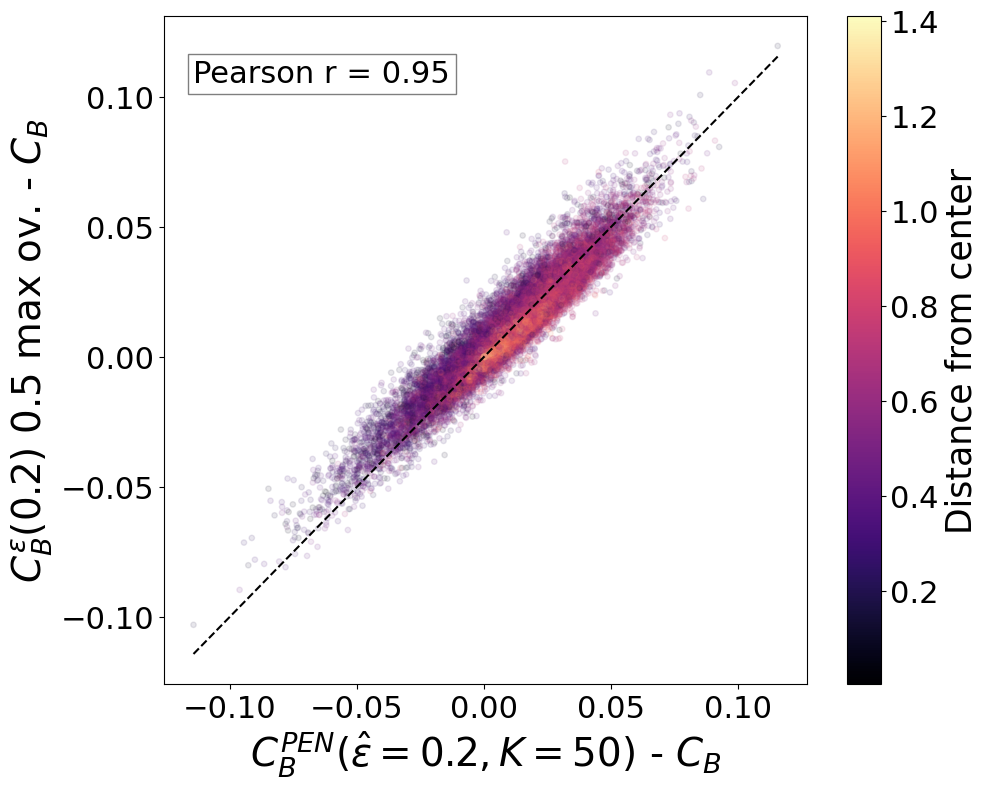

max value: 0.030091123638076714 at position: [0.69995431 0.0434692 ]


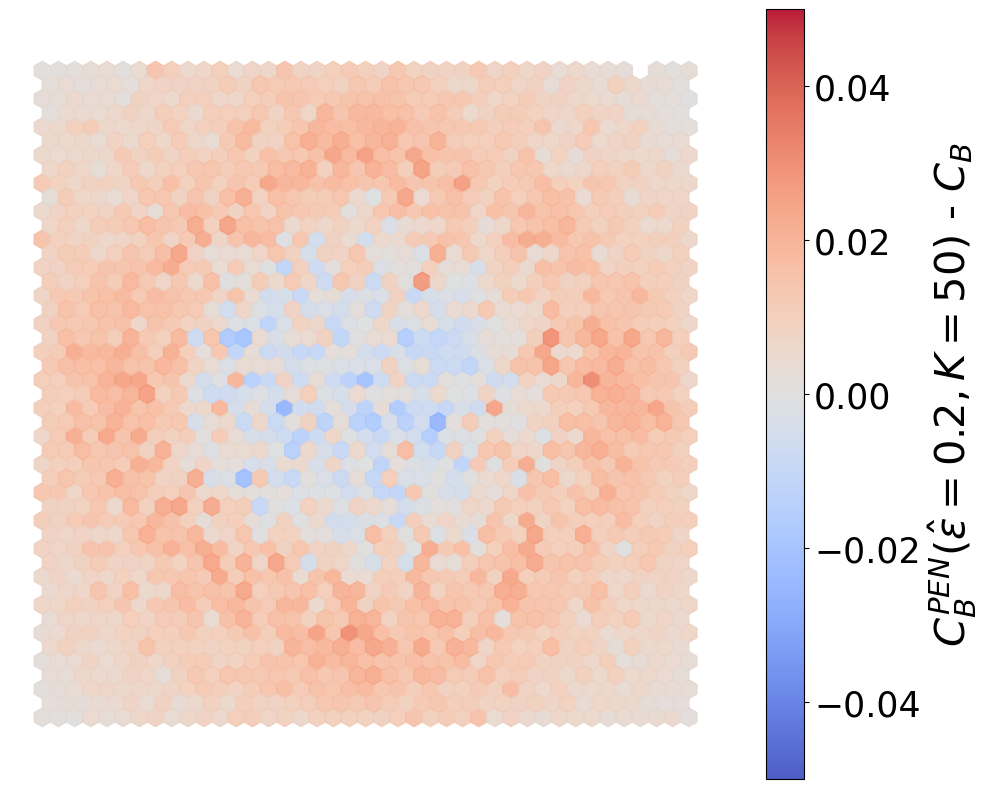

max value: 0.030277035138287327 at position: [0.57495849 0.17389866]


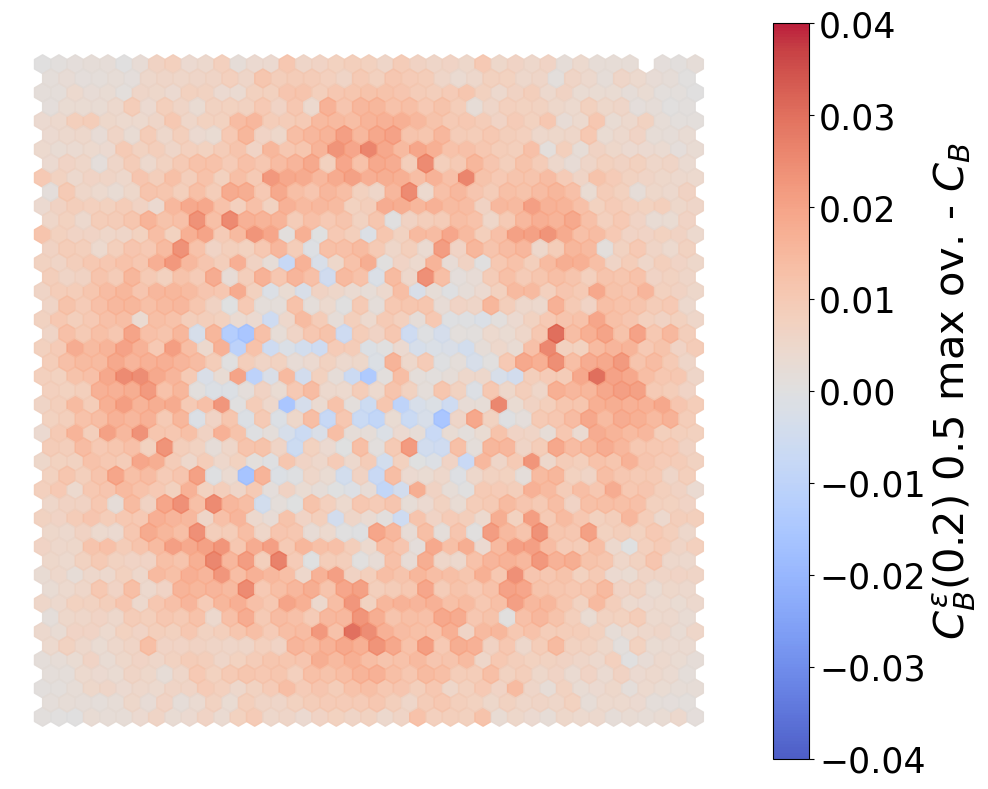

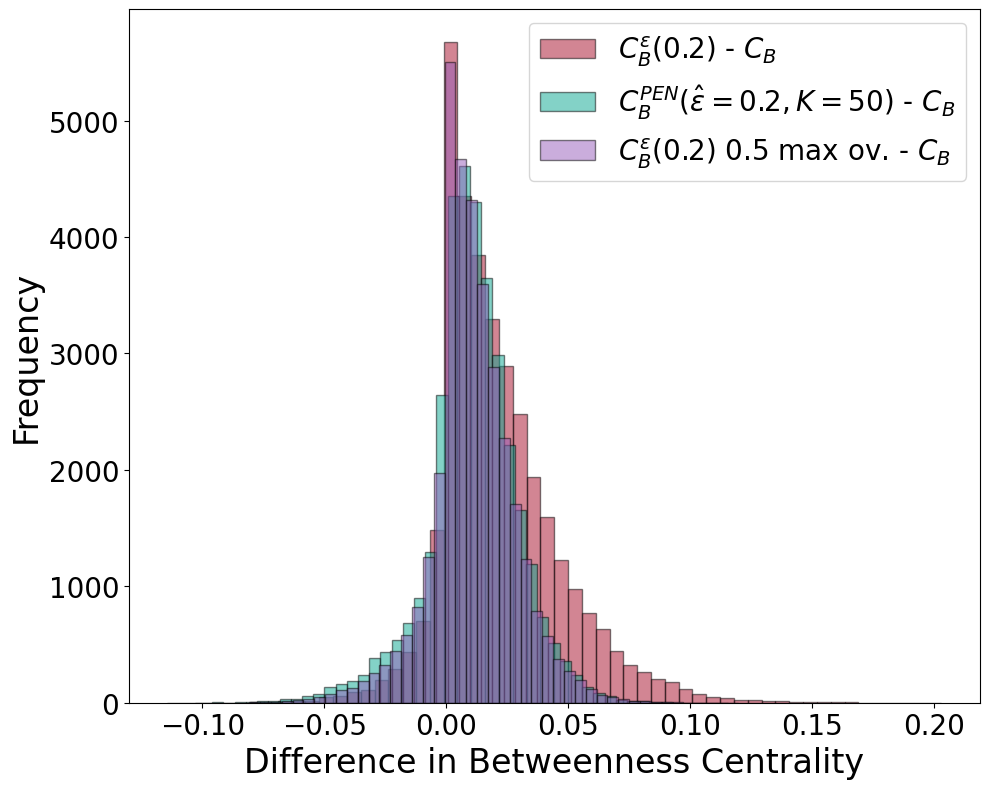

In [8]:
# plot correlation
import plot_utils as pu
import importlib
importlib.reload(pu)
print(len(qsp_bwss_ov_ls)/58)
print(qsp_bwss_ov_ls, sp_bwss_ls, pen_bwss_ls)
pen_bwss_ls = np.array(pen_bwss_ls)
qsp_bwss_ov_ls = np.array(qsp_bwss_ov_ls)
sp_bwss_ls = np.array(sp_bwss_ls)
p_r = pearsonr(pen_bwss_ls-sp_bwss_ls, qsp_bwss_ov_ls-sp_bwss_ls)
s_r = spearmanr(pen_bwss_ls-sp_bwss_ls, qsp_bwss_ov_ls-sp_bwss_ls)
plt.figure(figsize=(10, 8))
plt.xlabel(r'$C_B^{PEN} (\hat{\varepsilon} = 0.2, K=50)$ - $C_B$', fontsize = 28)
plt.ylabel(r'$C^{\varepsilon}_B(0.2)$ 0.5 max ov. - $C_B$', fontsize = 28)
plt.xticks(fontsize = 22)
plt.yticks(fontsize = 22)
r = np.sqrt(np.array(x_pos_tot)**2 + np.array(y_pos_tot)**2)
sc = plt.scatter(pen_bwss_ls-sp_bwss_ls, qsp_bwss_ov_ls-sp_bwss_ls, s = 15, alpha = 0.1, c = r, cmap='magma')
line = np.linspace(min(pen_bwss_ls-sp_bwss_ls), max(pen_bwss_ls-sp_bwss_ls), 100)
plt.text(np.min(line), np.max(line)-0.01, f'Pearson r = {p_r[0]:.2f}',# \nSpearman r = {s_r[0]:.2f}', 
         fontsize=22, bbox=dict(facecolor='white', alpha=0.5))
plt.plot(line, line, c = 'k', linestyle = '--', label = 'y = x')
# plt.hlines(0, xmin=min(line), xmax=max(line), colors='black', linestyles='dashed')
# plt.vlines(0, ymin=min(line), ymax=max(line), colors='black', linestyles='dashed')
#plot colorbar
cbar = plt.colorbar(sc)
cbar.set_alpha(1)
cbar.set_label('Distance from center', fontsize=25)
cbar.ax.tick_params(labelsize=22)
cbar.draw_all()
plt.tight_layout()
plt.savefig('./figs/fig_9_c.png', format='png')

plt.show()  

pu.plot_hexbin_with_max(
    x_pos_tot, y_pos_tot, np.array(pen_bwss_ls)-np.array(sp_bwss_ls),
    gridsize=40, mincnt=1,
    vmin=-0.05, vmax=0.05,
    cmap_name='coolwarm',
    max_marker_radius=0,
    axis_off=True,
    annotate_max=False,
    cbar_label=r'$C_B^{PEN} (\hat{\varepsilon} = 0.2, K=50)$ - $C_B$',
);
plt.tight_layout()
plt.savefig('./figs/fig_9_b.pdf', format='pdf')

plt.show()


pu.plot_hexbin_with_max(
    x_pos_tot, y_pos_tot, np.array(qsp_bwss_ov_ls)-np.array(sp_bwss_ls),
    gridsize=40, mincnt=1,
    vmin=-0.04, vmax=0.04,
    cmap_name='coolwarm',
    max_marker_radius=0,
    axis_off=True,
    annotate_max=False,
    cbar_label=r'$C^{\varepsilon}_B(0.2)$ 0.5 max ov. - $C_B$',
);
plt.tight_layout()
plt.savefig('./figs/fig_9_a.pdf', format='pdf')
plt.show()

plt.figure(figsize=(10, 8))
plt.hist(qsp_bwss_ls - sp_bwss_ls, bins=50, alpha=0.5, label=r'$C_B^{\varepsilon}(0.2)$ - $C_B$', color='#A60C28', edgecolor='black')
plt.hist(pen_bwss_ls - sp_bwss_ls, bins=50, alpha=0.5, label=r'$C_B^{PEN} (\hat{\varepsilon} = 0.2, K=50)$ - $C_B$', color='#08A691', edgecolor='black')
plt.hist(qsp_bwss_ov_ls - sp_bwss_ls, bins=50, alpha=0.5, label=r'$C_B^{\varepsilon}(0.2)$ 0.5 max ov. - $C_B$', color='#965DBA', edgecolor='black')

plt.xlabel('Difference in Betweenness Centrality', fontsize=24)
plt.ylabel('Frequency', fontsize=24)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.tight_layout()
plt.tight_layout()
plt.savefig('./figs/fig_9_d.png', format='png')
plt.show()

# pu.plot_hexbin_with_max(
#     x_pos_tot, y_pos_tot, np.array(pen_bwss_ls),
#     gridsize=40, mincnt=1,
#     vmin=0, vmax=0.15,
#     cmap_name='magma',
#     max_marker_radius=0.05,
#     axis_off=False,
#     annotate_max=True,
#     cbar_label=r'K=50 BW',
# );
# plt.show()

# pu.plot_hexbin_with_max(
#     x_pos_tot, y_pos_tot, np.array(qsp_bwss_ov_ls),
#     gridsize=40, mincnt=1,
#     vmin= 0, vmax=0.15,
#     cmap_name='magma',
#     max_marker_radius=0.05,
#     axis_off=False,
#     annotate_max=True,
#     cbar_label=r'20% QSP-BW 0.5 ov',
# );
# plt.show()

# pu.plot_hexbin_with_max(
#     x_pos_tot, y_pos_tot, np.array(sp_bwss_ls),
#     gridsize=40, mincnt=1,
#     vmin= 0, vmax=0.15,
#     cmap_name='magma',
#     max_marker_radius=0.05,
#     axis_off=False,
#     annotate_max=True,
#     cbar_label=r'SP-BW',
# );
# plt.show()

# pu.plot_hexbin_with_max(
#     x_pos_tot, y_pos_tot, np.array(qsp_bwss_ls),
#     gridsize=40, mincnt=1,
#     vmin= 0, vmax=0.15,
#     cmap_name='magma',
#     max_marker_radius=0.05,
#     axis_off=False,
#     annotate_max=True,
#     cbar_label=r'20% QSP-BW',
# );
# plt.show()

## Plot of the betweenness of Barcelona

In [43]:
direct_bwss = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/KSP_python/other_path_sampling_methods/penalized_bwss/other/bcn_amb_full/03_tol/bcn_penbwss_t_03_k_20_p_01.csv'
pos_dir = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/osm_cities/pos/full/bcn_amb_node_pos.csv'
graph_dir = '/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/osm_cities/bcn_amb_graph.csv'

In [44]:
# read the graph
df = pd.read_csv(graph_dir)  # header handled automatically
print(df.head())
G = nx.from_pandas_edgelist(
    df, source="vertex1", target="vertex2",
    edge_attr=["travel_time", "maxspeed"], create_using=nx.Graph())
nnodes = len(G.nodes)

x_pos = list(np.zeros(nnodes))
y_pos = list(np.zeros(nnodes))

# read the node positions
with open(pos_dir, 'r') as csvfile:
    csvreader = csv.reader(csvfile, delimiter=',')
    csvreader.__next__()  # Skip header row
    for row in csvreader:
        if row[0].isdigit(): 
            x_pos[int(row[0])] = float(row[1])
            y_pos[int(row[0])] = float(row[2])


# compute SP betweenness
bwss_sp = nx.betweenness_centrality(G, normalized=True, weight='travel_time')
# store in list
sp_bwss = []
for node in range(len(G.nodes)):
    sp_bwss.append(bwss_sp[node])

pen_bwss = list()
with open(direct_bwss, 'r') as csvfile:
    csvreader = csv.reader(csvfile, delimiter=',')
    for i, row in enumerate(csvreader):

        pen_bwss.append(2 *(np.array(row, dtype=float)/ ((nnodes-1) * (nnodes-2))))

   vertex1  vertex2  travel_time maxspeed
0        0        1         81.3       30
1        0     3429         17.4       30
2        1        0         81.3       30
3        1     1293         17.2       30
4        1     1294         18.9       30


0.16978915733206668


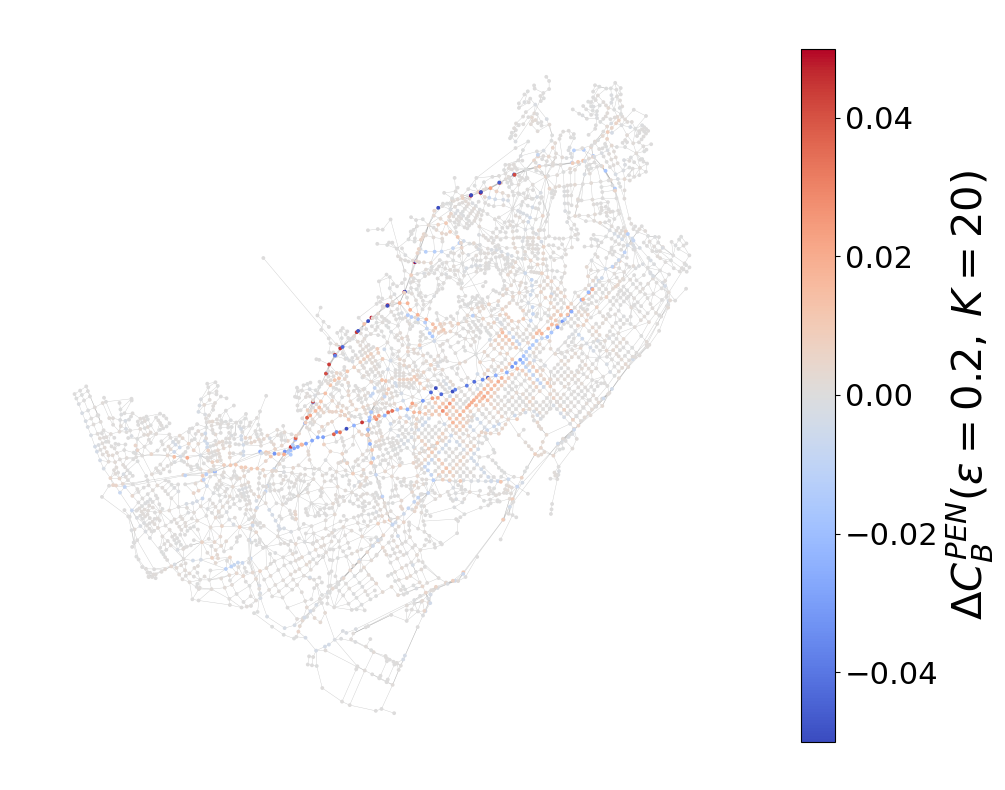

(417210.70392684714, 437612.4413726874, 4573192.146062619, 4592582.927773611)

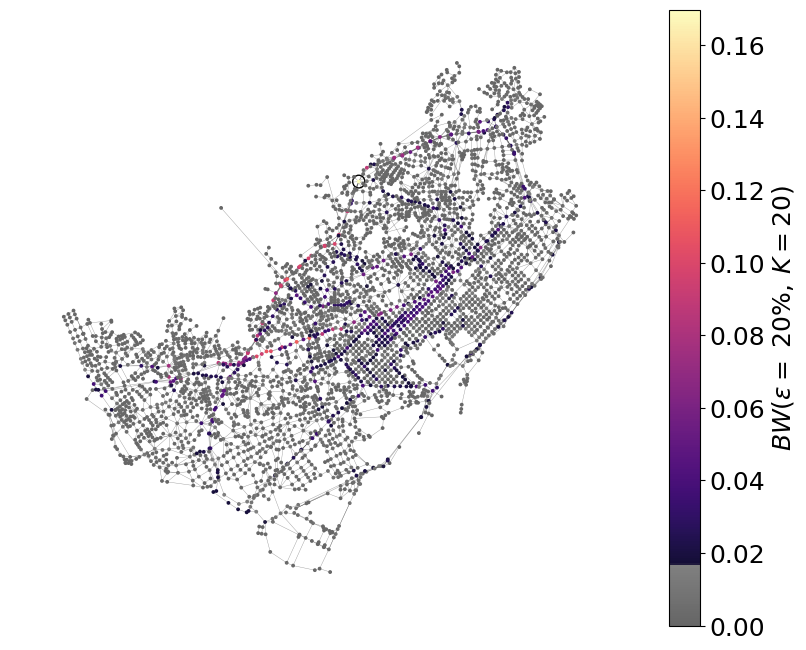

In [49]:
#plot the betweenness in the node positions
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import contextily as ctx
def gray_magma(gray_frac=0.2, n=256):
    magma = plt.cm.magma(np.linspace(gray_frac, 1, int(n*(1-gray_frac))))
    gray  = plt.cm.gray(np.linspace(0.4, 0.5, int(n*gray_frac)))
    colors = np.vstack((gray, magma))
    return LinearSegmentedColormap.from_list('gray_magma', colors)

cmap = gray_magma(gray_frac=0.1)

fig, ax = plt.subplots(figsize=(12, 10))
# sc = ax.scatter(x_pos, y_pos, c=np.array(pen_bwss[1])-np.array(pen_bwss[0]), cmap='RdBu_r', s=5,
#                 vmin=-0.02, vmax=0.02)
nodelist = list(range(nnodes))
tol_i = 2
pos = {n: (x_pos[n], y_pos[n]) for n in nodelist}
colors = (np.array(pen_bwss[tol_i]) - np.array(pen_bwss[0]))[nodelist]  # same order
vmax_vmin = np.max(np.abs(colors))
sc = nx.draw_networkx_nodes(
    G, pos=pos, nodelist=nodelist,
    node_size=3, node_color=colors,
    cmap='coolwarm', vmin=-0.05, vmax=0.05, ax=ax
)
nx.draw_networkx_edges(G, pos=pos, ax=ax, alpha=0.4, edge_color='gray', width=0.3)
max_v_i = np.argmax(np.array(pen_bwss[tol_i]))
print(pen_bwss[tol_i][max_v_i])
max_v_pos = (x_pos[max_v_i], y_pos[max_v_i])
# draw circle around max node
# circle = plt.Circle(max_v_pos, 200, color='black', fill=False, linewidth=1)
# ax.add_artist(circle)
# create colorbar and set label fontsize
cbar = plt.colorbar(sc, shrink=0.9)
cbar.set_label(r'$\Delta C_B^{PEN}(\varepsilon = 0.2, \: K=20)$', fontsize=30)
cbar.ax.tick_params(labelsize=22)

ax.axis('off')
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
colors = np.array(pen_bwss[tol_i])[nodelist]  # same order
sc = nx.draw_networkx_nodes(
    G, pos=pos, nodelist=nodelist,
    node_size=3, node_color=colors,
    cmap=cmap, vmin=0, vmax=np.max(colors), ax=ax)

nx.draw_networkx_edges(G, pos=pos, ax=ax, alpha=0.4, edge_color='k', width=0.3)
# draw circle around max node
circle = plt.Circle(max_v_pos, 200, color='black', fill=False, linewidth=1)
ax.add_artist(circle)
# create colorbar and set label fontsize
cbar = plt.colorbar(sc, shrink=1)
cbar.set_label(r'$BW(\varepsilon = $'+f' {tol_i*10}'+r'$\%, \: K=20)$', fontsize=18)
cbar.ax.tick_params(labelsize=18)

ax.axis('off')

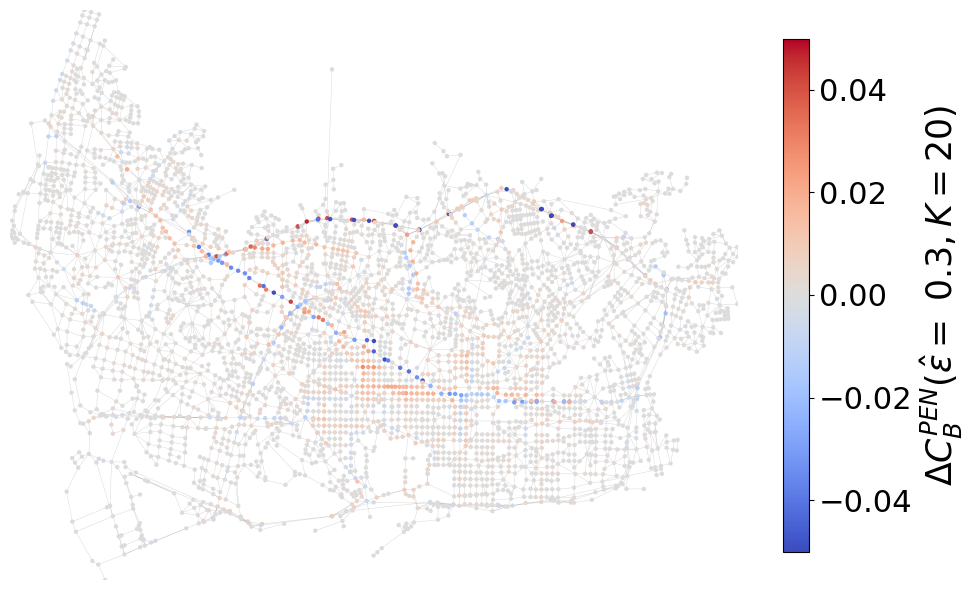

In [62]:
# Working example: draw your NetworkX graph on top of an OSM “ink-like” basemap
# Requires: pip install contextily

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import contextily as cx
from matplotlib.colors import LinearSegmentedColormap
from PIL import UnidentifiedImageError

def gray_magma(gray_frac=0.1, n=256):
    magma = plt.cm.magma(np.linspace(gray_frac, 1, int(n*(1-gray_frac))))
    gray  = plt.cm.gray(np.linspace(0.4, 0.5, int(n*gray_frac)))
    colors = np.vstack((gray, magma))
    return LinearSegmentedColormap.from_list('gray_magma', colors)

def plot_with_basemap(G, x_pos, y_pos, pen_bwss, tol_i=1, nnodes=None,
                      basemap_crs="EPSG:3857", rotation=0, ink_like=True,
                      circle_radius=200, add_basemap=False):

    if nnodes is None:
        nnodes = len(x_pos)

    nodelist = list(range(nnodes))
    pos = {n: (x_pos[n], y_pos[n]) for n in nodelist}
    pos_rot = rotate_points(pos, angle_deg=-45)

    x_pos_rot = [pos_rot[n][0] for n in nodelist]
    y_pos_rot = [pos_rot[n][1] for n in nodelist]

    # --- figure ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # Set bounds so contextily knows what to fetch
    ax.set_xlim(np.min(x_pos_rot), np.max(x_pos_rot))
    ax.set_ylim(np.min(y_pos_rot), np.max(y_pos_rot))

    # --- overlay: nodes/edges ---
    colors = (np.array(pen_bwss[tol_i]) - np.array(pen_bwss[0]))[nodelist]

    sc = nx.draw_networkx_nodes(
        G, pos=pos_rot, nodelist=nodelist,
        node_size=10, node_color=colors,
        cmap='coolwarm', vmin=-0.05, vmax=0.05,
        ax=ax, linewidths=0, alpha=1
    )

    nx.draw_networkx_edges(
        G, pos=pos_rot, ax=ax,
        alpha=0.35, edge_color='gray', width=0.3
    )

    # --- highlight max node (optional) ---
    max_v_i = int(np.argmax(np.array(pen_bwss[tol_i])))
    max_v_pos = (x_pos[max_v_i], y_pos[max_v_i])
    ax.add_artist(plt.Circle(max_v_pos, circle_radius, color='black', fill=False, linewidth=1))

    # --- basemap underlay ---
    source = cx.providers.CartoDB.PositronNoLabels
    if add_basemap:
        try:
            cx.add_basemap(ax, crs=basemap_crs, source=source, alpha=0.95, zorder=0)
        except UnidentifiedImageError:
            # fallback to a different provider if a tile image cannot be identified
            print("Warning: basemap tile image couldn't be identified. Falling back to OpenStreetMap.Mapnik")
            try:
                cx.add_basemap(ax, crs=basemap_crs, source=cx.providers.CartoDB.PositronNoLabels, alpha=0.95, zorder=0)
            except Exception as e:
                print("Failed to add basemap fallback:", e)
        except Exception as e:
            # catch other contextily/PIL errors and continue without crashing
            print("Warning: failed to add basemap:", e)
            
    # --- colorbar ---
    cbar = plt.colorbar(sc, ax=ax, shrink=0.9)
    cbar.set_label(r'$\Delta C_B^{PEN}(\hat{\varepsilon} =$'+f' {tol_i/10},'+r'$\: K=20)$', fontsize=25)
    cbar.ax.tick_params(labelsize=22)

    ax.axis('off')
    plt.tight_layout()
# ---------------------------
# USAGE:
# - If your x_pos/y_pos are meters in Web Mercator: basemap_crs="EPSG:3857" (default)
# - If your x_pos/y_pos are lon/lat degrees: basemap_crs="EPSG:4326"
# ---------------------------

def rotate_points(pos, angle_deg, center=None):
    angle = np.deg2rad(angle_deg)
    R = np.array([[np.cos(angle), -np.sin(angle)],
                  [np.sin(angle),  np.cos(angle)]])

    coords = np.array(list(pos.values()))

    if center is None:
        center = coords.mean(axis=0)

    rotated = (coords - center) @ R.T + center
    return dict(zip(pos.keys(), rotated))


# Example call (uses your existing variables):
plot_with_basemap(
    G=G,
    x_pos=x_pos,
    y_pos=y_pos,
    pen_bwss=pen_bwss,
    tol_i=3,
    nnodes=nnodes,
    basemap_crs="EPSG:32631",  # change to "EPSG:4326" if x_pos/y_pos are lon/lat
    rotation = 45,
    ink_like=True,
    circle_radius=0
)
plt.savefig('./figs/fig_10_a.png', format='png')
plt.show()


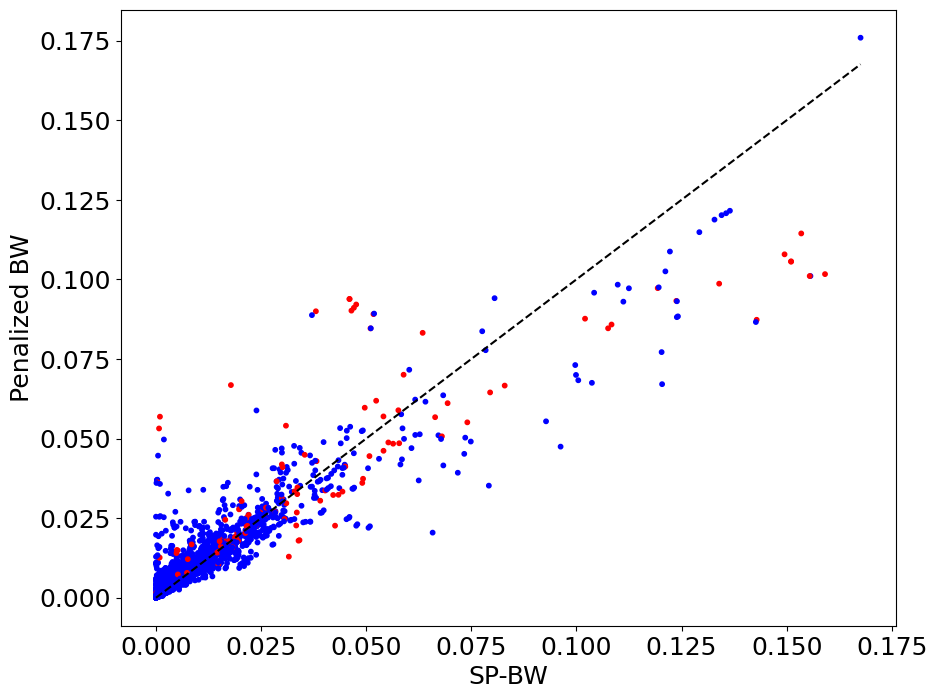

In [195]:
import ast
# plot correlation between speed of surrounding edges and betweenness difference
from scipy.stats import pearsonr, spearmanr
max_weights = []

for node in range(len(G.nodes)):
    neigh_edges = G.edges(node, data='maxspeed')
    weights = []
    for u, v, w in neigh_edges:
        try:
            weights.append(float(w))
        except:
            w = ast.literal_eval(w)
            max_w = np.nanmax(np.array(w, dtype=float))
            weights.append(max_w)
        #print(weights if np.isnan(weights).all() else '')
    max_weights.append(np.max(weights))

highspeed = np.array(max_weights) > 50
colors_hi = ['r' if hs else 'b' for hs in highspeed]
fig, ax = plt.subplots(figsize=(10, 8))
plt.xlabel('SP-BW', fontsize = 18)
plt.ylabel('Penalized BW', fontsize = 18)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.scatter(sp_bwss, pen_bwss[1], s = 10, alpha = 1, c = colors_hi)#, cmap='inferno')
#plt.colorbar(label='Max speed of surrounding edges')
line = np.linspace(min(sp_bwss), max(sp_bwss), 100)
plt.plot(line, line, c = 'k', linestyle = '--', label = 'y = x')
# plt.scatter(max_weights, pen_bwss[3]-sp_bwss, s = 10, alpha = 0.5, c = pen_bwss[3]-sp_bwss, cmap='coolwarm', vmax=0.05, vmin=-0.05)

plt.show()    

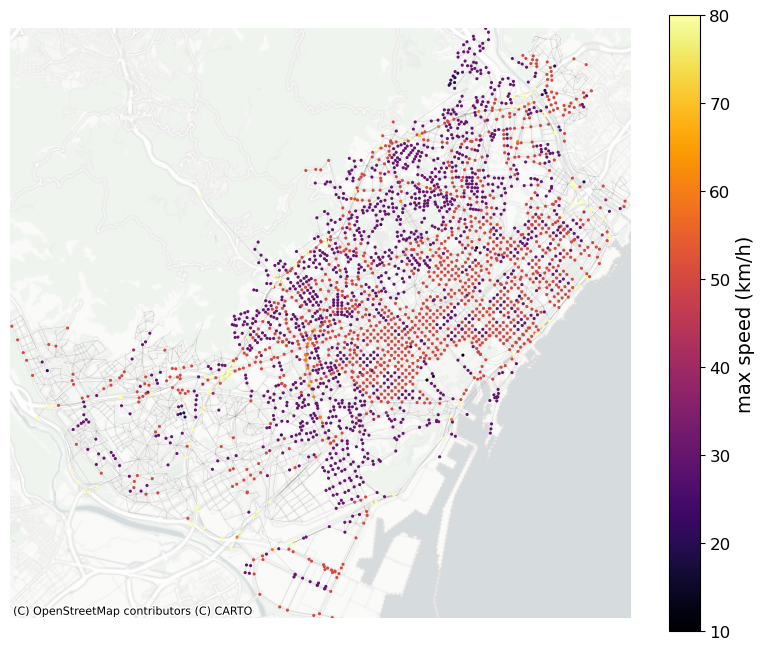

In [197]:
nodelist = list(range(nnodes))
pos = {n: (x_pos[n], y_pos[n]) for n in nodelist}

# --- figure ---
fig, ax = plt.subplots(figsize=(10, 8))

# Set bounds so contextily knows what to fetch
ax.set_xlim(np.min(x_pos), np.max(x_pos))
ax.set_ylim(np.min(y_pos), np.max(y_pos))

# --- basemap underlay ---
basemap_crs="EPSG:32631"
source = cx.providers.CartoDB.PositronNoLabels
try:
    cx.add_basemap(ax, crs=basemap_crs, source=source, alpha=0.95, zorder=0)
except UnidentifiedImageError:
    # fallback to a different provider if a tile image cannot be identified
    print("Warning: basemap tile image couldn't be identified. Falling back to OpenStreetMap.Mapnik")
    try:
        cx.add_basemap(ax, crs=basemap_crs, source=cx.providers.CartoDB.PositronNoLabels, alpha=0.95, zorder=0)
    except Exception as e:
        print("Failed to add basemap fallback:", e)
except Exception as e:
    # catch other contextily/PIL errors and continue without crashing
    print("Warning: failed to add basemap:", e)

# --- overlay: nodes/edges ---
colors = np.array(max_weights)[nodelist]

sc = nx.draw_networkx_nodes(
    G, pos=pos, nodelist=nodelist,
    node_size=5, node_color=colors,
    cmap='inferno',ax=ax, linewidths=0, alpha=1
)

nx.draw_networkx_edges(
    G, pos=pos, ax=ax,
    alpha=0.35, edge_color='gray', width=0.3
)

# --- colorbar ---
cbar = plt.colorbar(sc, ax=ax, shrink=1.0)
cbar.set_label(r'max speed (km/h)', fontsize=14)
cbar.ax.tick_params(labelsize=12)

ax.axis('off')
plt.show()
